In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

In [2]:
size = 50
moisture = np.random.rand(size,size)

In [3]:
def tree(density,size):
    tree = np.random.choice([0,1], size = (size,size), p = [1-density, density])
    return tree

In [4]:
def diffuse (m, D=0.1):
    new_m = m.copy()
    for i in range(1, size-1):
        for j in range(1,size-1):
            neighbors = [m[i+1,j],m[i-1,j],m[i,j+1],m[i,j-1]]
            new_m[i,j]+= D*(np.sum(neighbors) - 4*m[i,j])
    return new_m

In [5]:
def uptake(m, trees, rate=0.05):
    return m - rate*trees

In [6]:
#values of evap_wilting and evap_max need to be verified
def evapotranspiration(m,trees, evap_wilting = 0.01, evap_max=0.03, maxevap_pt = 0.4, wilting_pt = 0.15, hygroscopic_pt = 0.05, shade_factor=0.5):
    new_m = m.copy()
    for i in range(size):
        for j in range(size):
            if m[i,j] <= hygroscopic_pt:
                new_m[i,j] = m[i,j]
            elif m[i,j] <= wilting_pt:
                new_m[i,j] = m[i,j] - evap_wilting*((m[i,j]- hygroscopic_pt)/(wilting_pt - hygroscopic_pt))
            elif m[i,j] <= maxevap_pt:
                new_m[i,j] = m[i,j] - evap_wilting - (evap_max - evap_wilting)*((m[i,j] - wilting_pt)/(maxevap_pt - wilting_pt))
            else:
                new_m[i,j] = m[i,j] - evap_max
    return np.clip(new_m,0,None)

In [7]:
def rain_input(m, trees, lam=0.1, interception=2):
    new_m = m.copy()
    rain_today = np.random.poisson(lam)>0
    if rain_today:
        depth = np.random.exponential(15)
        for i in range(size):
            for j in range(size):
                new_m[i,j] = max(m[i,j], m[i,j] + (depth - interception))
    return new_m

In [8]:
def final_moisture(m, trees, lam=0.1, interception=2, evap_wilting=0.01, evap_max=0.03, maxevap_pt=0.4, wilting_pt=0.15, hygroscopic_pt=0.05, shade_factor=0.5 , D=0.1, sweeps=365):
    state = m.copy()
    for t in range(sweeps):
        state = diffuse(state,D)
        state = evapotranspiration(state, trees, evap_wilting, evap_max, maxevap_pt, wilting_pt, hygroscopic_pt, shade_factor)
        state = rain_input(state, trees, lam, interception)
    return state

In [9]:
def average_moisture(m, trees, lam, interception, evap_wilting, evap_max, maxevap_pt, wilting_pt, hygroscopic_pt, shade_factor, D, sweeps):
    final_state = final_moisture(m, trees, lam, interception, evap_wilting, evap_max, maxevap_pt, wilting_pt, hygroscopic_pt, shade_factor, D, sweeps)
    average = np.mean(final_state)
    return average

[np.float64(390.82064355423313), np.float64(498.4472593546535), np.float64(570.694567884729), np.float64(675.9481886812972), np.float64(445.535484259069), np.float64(563.8308520658452), np.float64(756.0634614527843), np.float64(474.07402315057294), np.float64(456.10094508051725), np.float64(306.7887977240125), np.float64(407.5727577939492), np.float64(582.7155942762986), np.float64(393.0412547272902), np.float64(533.9684921744317), np.float64(602.6957567622655), np.float64(264.2072347422548), np.float64(303.5807461045758), np.float64(431.35180975389073), np.float64(429.78468273290173), np.float64(492.4589816275591), np.float64(240.54663246200755), np.float64(656.6546512713652), np.float64(337.50664142657837), np.float64(490.5638714966543), np.float64(512.135146462858), np.float64(525.681637774024), np.float64(424.4645076297149), np.float64(321.4965704738884), np.float64(630.097935688473), np.float64(390.8368655439795), np.float64(379.9848870002035), np.float64(359.06674964879943), np.f

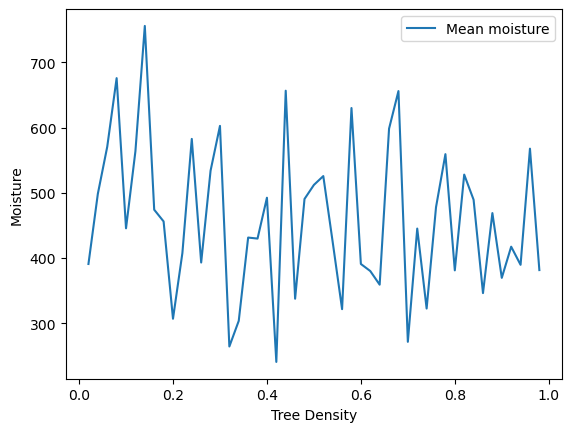

In [10]:
mean_moisture = []
density_list = []
for d in range(1,50):
    density = d* 0.02
    trees = tree(density,50)
    final_state = final_moisture(moisture, trees, 0.1, 2, 0.01, 0.03, 0.04, 0.15, 0.05, 0.5,0.1, 365)
    average = average_moisture(moisture, trees, 0.1, 2, 0.01, 0.03, 0.04, 0.15, 0.05, 0.5,0.1,365)
    mean_moisture.append(average)
    density_list.append(density)

print(mean_moisture)

plt.plot(density_list, mean_moisture, label = "Mean moisture")
plt.legend()
plt.xlabel("Tree Density")
plt.ylabel("Moisture")
plt.show()